<a href="https://colab.research.google.com/github/Igbasanmi01/my-colab-project/blob/main/FYBProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consolidated Data Processing and Model Training Workflow

In [ ]:
# 1. Authenticate the user
from google.colab import auth
auth.authenticate_user()

# 2. Import required libraries
import gspread
from google.auth import default
import pandas as pd

# 3. Authorize gspread with your credentials
creds, _ = default()
gc = gspread.authorize(creds)

# 4. Open the Google Sheet by its title
# Replace 'Your Google Sheet Title Here' with the exact name of your spreadsheet
spreadsheet_name = 'Student Feedback Project'
spreadsheet = gc.open(spreadsheet_name)

# Get all worksheet titles to help debug if the intended worksheet isn't found
worksheet_titles = [ws.title for ws in spreadsheet.worksheets()]
print(f"Available worksheets: {worksheet_titles}")

# 5. Select the first worksheet (usually "Form Responses 1") or by its exact title
# The previous error suggested 'Form Responses 3' was not found or was misspelled.
# We'll use index 0 for now and print available titles for you to choose.
worksheet = spreadsheet.get_worksheet(0)

# 6. Read all data into a list of dictionaries and convert to a Pandas DataFrame
data = worksheet.get_all_records()
df = pd.DataFrame(data)

# View the latest data shape and the last few rows
print(f"Data updated successfully! Current shape: {df.shape}")
df.tail()

Available worksheets: ['Form Responses 4', 'Form Responses 3', 'Copy of Form Responses 3']
Data updated successfully! Current shape: (1000, 12)


,Timestamp,Gender,Level,Hall of Residence,When do you visit the clinic,Which unit made you dissatisfied or satisfied,"How was your clinical experience (Based on the unit you choose)\nE.G ""The nurse was very helpful but drug collection was slow""",Why were you dissatisfied?\n,How was the treatment like with the staff,Prescribed Drugs,Functional Equipment,How long did you spend in the clinic during your visit
995,6/4/2026 7:17:32,Female,100,New Elizabeth Hall,Morning,Doctor Consultation,It's not too good,None,3,Partially Available,Partially Available,30-60 mins
996,6/4/2026 7:18:36,Male,200,New Elizabeth Hall,Morning,Reception,"It's just an average clinic to me, nothing ser...",None,3,Partially Available,Partially Available,30-60 mins
997,6/4/2026 7:20:07,Female,100,New Elizabeth Hall,Evening,Pharmacy,I wonder how much the drugs the buy it's does...,Lack of specific resource,3,Partially Available,Partially Available,1-2 hrs
998,6/4/2026 7:22:41,Female,100,New Elizabeth Hall,Evening,Nursing,Needs better improvement,Lack of specific resource,3,Partially Available,Partially Available,30-60 mins
999,6/4/2026 7:25:52,Female,200,Elizabeth 1,Morning,Doctor Consultation,Zero stress,None,5,Fully Available,Fully Available,30-60 mins


In [ ]:
# from google.colab import auth
# auth.authenticate_user()
# import gspread
# from google.auth import default
# creds, _ = default()
# gc = gspread.authorize(creds)

In [ ]:
# # import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # !pip install torch transformers datasets scikit-learn

# df = pd.read_csv('/content/drive/MyDrive/Student Feedback Project - Form Responses 3.csv')
# # df = pd.read_csv('/content/drive/MyDrive/Copy of Student Feedback Main.csv.gsheet')

# display(df.head())

In [ ]:
%pip install emoji
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype 
---  ------                                                                                                                         --------------  ----- 
 0   Timestamp                                                                                                                      1000 non-null   object
 1   Gender                                                                                                                         1000 non-null   object
 2   Level                                                                                                                          1000 non-null   object
 3   Hall of Residence                                                                                                 

In [ ]:
import emoji
import re

def advanced_clean_text(text):
    # 1. Convert to string and lowercase
    text = str(text).lower()

    # 2. Demojize first (Turn 😊 into "smiling face")
    # We do this BEFORE regex so the emojis aren't deleted
    text = emoji.demojize(text)

    # 3. Clean up the emoji text (Remove colons and underscores)
    text = text.replace(":", " ").replace("_", " ")

    # 4. Now use Regex to remove special characters
    # (Keeping only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
df.columns

Index(['Timestamp', 'Gender', 'Level', 'Hall of Residence',
       'When do you visit the clinic',
       'Which unit made you dissatisfied or satisfied',
       'How was your clinical experience (Based on the unit you choose)\nE.G "The nurse was very helpful but drug collection was slow"',
       'Why were you dissatisfied?\n',
       'How was the treatment like with the staff', 'Prescribed Drugs',
       'Functional Equipment',
       'How long did you spend in the clinic during your visit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype 
---  ------                                                                                                                         --------------  ----- 
 0   Timestamp                                                                                                                      1000 non-null   object
 1   Gender                                                                                                                         1000 non-null   object
 2   Level                                                                                                                          1000 non-null   object
 3   Hall of Residence                                                                                                 

In [ ]:
# df['Why were you dissatisfied?\n'].fillna('None')
# display(df[df['Why were you dissatisfied?\n'].isnull()])

In [ ]:
# df.isnull().sum()

In [ ]:
df.columns

Index(['Timestamp', 'Gender', 'Level', 'Hall of Residence',
       'When do you visit the clinic',
       'Which unit made you dissatisfied or satisfied',
       'How was your clinical experience (Based on the unit you choose)\nE.G "The nurse was very helpful but drug collection was slow"',
       'Why were you dissatisfied?\n',
       'How was the treatment like with the staff', 'Prescribed Drugs',
       'Functional Equipment',
       'How long did you spend in the clinic during your visit'],
      dtype='object')

In [ ]:
df.rename(columns={'Why were you dissatisfied?\n': 'Why were you dissatisfied'}, inplace=True)

In [ ]:
df.columns

Index(['Timestamp', 'Gender', 'Level', 'Hall of Residence',
       'When do you visit the clinic',
       'Which unit made you dissatisfied or satisfied',
       'How was your clinical experience (Based on the unit you choose)\nE.G "The nurse was very helpful but drug collection was slow"',
       'Why were you dissatisfied',
       'How was the treatment like with the staff', 'Prescribed Drugs',
       'Functional Equipment',
       'How long did you spend in the clinic during your visit'],
      dtype='object')

### Data Preprocessing

#### Level Column

In [ ]:
print(df['Level'].value_counts())

Level
200          282
400          280
300          209
100          207
500           11
400 level      2
400lvl         2
400 Level      1
200lvl         1
4              1
300L           1
200lvl         1
100-200        1
200 LEVEL      1
Name: count, dtype: int64


In [ ]:
# Cleaning the 'Level' column
df['Level'] = df['Level'].astype(str).str.upper().str.strip()

level_mapping = {
    '400 LEVEL': '400',
    '400LVL': '400',
    '200LVL': '200',
    '200 LEVEL': '200',
    '300L': '300',
    '4': '400',
    '100-200': '100'
}

df['Level'] = df['Level'].replace(level_mapping)

# Checking distribution after cleaning
print(df['Level'].value_counts())

Level
400    286
200    285
300    210
100    208
500     11
Name: count, dtype: int64


### Hall of Residence Column

In [ ]:
print(df['Hall of Residence'].value_counts())

Hall of Residence
New Elizabeth Hall       236
New Daniel Hall          187
New Elizabeth Hall 2     109
Elizabeth 1               95
House of Daniel           95
Daniel 1                  57
Elizabeth 3               43
Elizabeth 2               29
Guest House               27
Regional House            24
E1                        12
E3                         8
D1                         8
NEH                        6
NDH                        6
e1                         5
E2                         5
HOD                        4
Ndh                        3
NEH 2                      3
Regional house             3
ELIZABETH 1                2
House of Daniel            2
REGIONAL HOUSE             2
Elizabeth Hall 3           1
New Elizabeth Hall 1       1
New Daniel Hall            1
NEW ELIZABETH 1            1
NEH1                       1
regional house             1
neh 1                      1
ELIZABETH ONE HALL         1
New daniel hall            1
Hod                      

In [ ]:
display(df[df['Hall of Residence'] == 'NDH-NEH']['Gender'])

,Gender
114,"Male, Female"


In [ ]:
# display(df[df['Hall of Residence'] == "CHMS"])
# display(df[df['Hall of Residence'] == 'NDH-NEH'])

In [ ]:
# Dropping the row where 'Hall of Residence' is 'NDH-NEH'
df.drop(df[df['Hall of Residence'] == 'NDH-NEH'].index, inplace=True)

# Display the value counts after dropping the row
print(df['Hall of Residence'].value_counts())

Hall of Residence
New Elizabeth Hall       236
New Daniel Hall          187
New Elizabeth Hall 2     109
House of Daniel           95
Elizabeth 1               95
Daniel 1                  57
Elizabeth 3               43
Elizabeth 2               29
Guest House               27
Regional House            24
E1                        12
D1                         8
E3                         8
NDH                        6
NEH                        6
E2                         5
e1                         5
HOD                        4
Ndh                        3
Regional house             3
NEH 2                      3
REGIONAL HOUSE             2
ELIZABETH 1                2
House of Daniel            2
New Elizabeth Hall 1       1
New Daniel Hall            1
NEH1                       1
NEW ELIZABETH 1            1
Elizabeth Hall 3           1
neh 1                      1
House Of Daniel            1
regional house             1
d1                         1
ELIZABETH ONE HALL       

In [ ]:
hall_mapping = {
     'NEW ELIZABETH HALL 1': 'New Elizabeth Hall',
     'NEW ELIZABETH HALL': 'New Elizabeth Hall',
     'NEH': 'New Elizabeth Hall',
     'NEH1': 'New Elizabeth Hall',
     'NEH 1': 'New Elizabeth Hall',
     'NEW ELIZABETH 1': 'New Elizabeth Hall',
     'ELIZABETH NEW HALL': 'New Elizabeth Hall',
     'Elizabeth Hall': 'New Elizabeth Hall',
     'ELIZABETH HALL': 'New Elizabeth Hall',

     'NEW DANIEL HALL': 'New Daniel Hall',
     'NDH': 'New Daniel Hall',
     'NEW DANIEL HALL 1': 'New Daniel Hall',

     'ELIZABETH 1': 'Elizabeth 1',
     'E1': 'Elizabeth 1',
     'ELIZABETH ONE HALL': 'Elizabeth 1',
     'ELIZABETH HALL 1': 'Elizabeth 1',

     'HOUSE OF DANIEL': 'House of Daniel',
     'HOD': 'House of Daniel',

     'DANIEL 1': 'Daniel 1',
     'D1': 'Daniel 1',
     'DANIEL HALL 1': 'Daniel 1',
     'DANEIL 1': 'Daniel 1',

     'NEW ELIZABETH HALL 2': 'New Elizabeth Hall 2',
     'NEH 2': 'New Elizabeth Hall 2',
     'NEW ELIZABETH 2': 'New Elizabeth Hall 2',
     'NEW 2 ELIZABETH': 'New Elizabeth Hall 2',

     'ELIZABETH 2': 'Elizabeth 2',
     'E2': 'Elizabeth 2',
     'ELISABETH 2 HALL': 'Elizabeth 2',

     'ELIZABETH 3': 'Elizabeth 3',
     'E3': 'Elizabeth 3',
     'ELIZABETH HALL 3': 'Elizabeth 3',

     'REGIONAL HOUSE': 'Regional House',
     'GUEST HOUSE': 'Guest House',

     'CHMS': 'New Elizabeth Hall'
}

# # Print the mapping for review
print(hall_mapping)

{'NEW ELIZABETH HALL 1': 'New Elizabeth Hall', 'NEW ELIZABETH HALL': 'New Elizabeth Hall', 'NEH': 'New Elizabeth Hall', 'NEH1': 'New Elizabeth Hall', 'NEH 1': 'New Elizabeth Hall', 'NEW ELIZABETH 1': 'New Elizabeth Hall', 'ELIZABETH NEW HALL': 'New Elizabeth Hall', 'Elizabeth Hall': 'New Elizabeth Hall', 'ELIZABETH HALL': 'New Elizabeth Hall', 'NEW DANIEL HALL': 'New Daniel Hall', 'NDH': 'New Daniel Hall', 'NEW DANIEL HALL 1': 'New Daniel Hall', 'ELIZABETH 1': 'Elizabeth 1', 'E1': 'Elizabeth 1', 'ELIZABETH ONE HALL': 'Elizabeth 1', 'ELIZABETH HALL 1': 'Elizabeth 1', 'HOUSE OF DANIEL': 'House of Daniel', 'HOD': 'House of Daniel', 'DANIEL 1': 'Daniel 1', 'D1': 'Daniel 1', 'DANIEL HALL 1': 'Daniel 1', 'DANEIL 1': 'Daniel 1', 'NEW ELIZABETH HALL 2': 'New Elizabeth Hall 2', 'NEH 2': 'New Elizabeth Hall 2', 'NEW ELIZABETH 2': 'New Elizabeth Hall 2', 'NEW 2 ELIZABETH': 'New Elizabeth Hall 2', 'ELIZABETH 2': 'Elizabeth 2', 'E2': 'Elizabeth 2', 'ELISABETH 2 HALL': 'Elizabeth 2', 'ELIZABETH 3': 

In [ ]:
# Standardize all values to uppercase and strip whitespace
df['Hall of Residence'] = df['Hall of Residence'].astype(str).str.upper().str.strip()

# Apply the mapping to clean the 'Hall of Residence' column
df['Hall of Residence'] = df['Hall of Residence'].replace(hall_mapping)

# Check distribution after cleaning
print(df['Hall of Residence'].value_counts())

Hall of Residence
New Elizabeth Hall      252
New Daniel Hall         199
Elizabeth 1             117
New Elizabeth Hall 2    114
House of Daniel         104
Daniel 1                 68
Elizabeth 3              53
Elizabeth 2              35
Regional House           30
Guest House              27
Name: count, dtype: int64


### Time Spent in the Clinic Column

In [ ]:
print("Value counts before replacement:")
print(df['How long did you spend in the clinic during your visit'].value_counts())

df['How long did you spend in the clinic during your visit'] = df['How long did you spend in the clinic during your visit'].str.replace('Option 3', '30-60 mins', regex=False)

print("\nValue counts after replacement:")
print(df['How long did you spend in the clinic during your visit'].value_counts())

Value counts before replacement:
How long did you spend in the clinic during your visit
1-2 hrs       472
30-60 mins    407
< 30 mins     112
Option 3        8
Name: count, dtype: int64

Value counts after replacement:
How long did you spend in the clinic during your visit
1-2 hrs       472
30-60 mins    415
< 30 mins     112
Name: count, dtype: int64


### Why were you dissatisfied Column

In [ ]:
# Dynamically determine the correct column name for 'Why were you dissatisfied'
dissatisfied_col_name = None
if 'Why were you dissatisfied' in df.columns:
    dissatisfied_col_name = 'Why were you dissatisfied'
elif 'Why were you dissatisfied?\n' in df.columns:
    dissatisfied_col_name = 'Why were you dissatisfied?\n'

if dissatisfied_col_name:
    # If the column name is the one with '\n', rename it for consistency
    if dissatisfied_col_name == 'Why were you dissatisfied?\n':
        df.rename(columns={'Why were you dissatisfied?\n': 'Why were you dissatisfied'}, inplace=True)
        dissatisfied_col_name = 'Why were you dissatisfied' # Update to the new name

    df[dissatisfied_col_name] = df[dissatisfied_col_name].fillna('None')
else:
    print("Error: 'Why were you dissatisfied' column not found in any expected format.")

In [ ]:
# Further cleaning for 'Why were you dissatisfied' column
print("Value counts before spelling correction:")
print(df['Why were you dissatisfied'].value_counts())

# Replace 'Not specified' with 'Lack of specific resource'
df['Why were you dissatisfied'] = df['Why were you dissatisfied'].str.replace('Option 3', 'Lack of specific resource')

# Correct spelling of 'Personnel's behavoiur'
df['Why were you dissatisfied'] = df['Why were you dissatisfied'].str.replace("Personnel's behavoiur", "Personnel's behaviour", regex=False)

#Replace 'Lack of specific resource, Option 3'
df['Why were you dissatisfied'] = df['Why were you dissatisfied'].str.replace("Lack of specific resource, Option 3", "Personnel's behaviour, Lack of specific resource", regex=False)

# Correct spelling in combined entries if they still exist after the first replacement
df['Why were you dissatisfied'] = df['Why were you dissatisfied'].str.replace("Personnel's behaviour, Lack of specific resource", "Personnel's behaviour, Lack of specific resource", regex=False)

#Replace 'Lack of specific resource, Lack of specific resource'
df['Why were you dissatisfied'] = df['Why were you dissatisfied'].str.replace("Lack of specific resource, Lack of specific resource", "Personnel's behaviour, Lack of specific resource", regex=False)

#Replace
df['Why were you dissatisfied'] = df['Why were you dissatisfied'].str.replace("Lack of specific resource, None", "None", regex=False)

print("\nValue counts after spelling correction and cleaning:")
print(df['Why were you dissatisfied'].value_counts())


Value counts before spelling correction:
Why were you dissatisfied
Lack of specific resource                           374
None                                                218
Personnel's behavoiur                               148
Personnel's behaviour                               139
Personnel's behavoiur, Lack of specific resource     92
Personnel's behaviour, Lack of specific resource     22
Option 3                                              3
Lack of specific resource, None                       2
Lack of specific resource, Option 3                   1
Name: count, dtype: int64

Value counts after spelling correction and cleaning:
Why were you dissatisfied
Lack of specific resource                           377
Personnel's behaviour                               287
None                                                220
Personnel's behaviour, Lack of specific resource    115
Name: count, dtype: int64


In [ ]:
# df.info()

### Functional Equipment and Prescribed Drugs

In [ ]:
print("Value counts before standardization:")
print(df['Functional Equipment'].value_counts())

df['Functional Equipment'] = df['Functional Equipment'].replace('Partially Available, Not Available', 'Partially Available', regex=False)

print("\nValue counts after standardization:")
print(df['Functional Equipment'].value_counts())

Value counts before standardization:
Functional Equipment
Partially Available                   686
Fully Available                       230
Not Available                          81
Partially Available, Not Available      2
Name: count, dtype: int64

Value counts after standardization:
Functional Equipment
Partially Available    688
Fully Available        230
Not Available           81
Name: count, dtype: int64


In [ ]:
print("Value counts before standardization:")
print(df['Prescribed Drugs'].value_counts())

df['Prescribed Drugs'] = df['Prescribed Drugs'].str.replace('Partially Available, Not Available', 'Partially Available')
df['Prescribed Drugs'] = df['Prescribed Drugs'].str.replace('Fully Available, Partially Available', 'Partially Available')

print("\nValue counts after standardization:")
print(df['Prescribed Drugs'].value_counts())

Value counts before standardization:
Prescribed Drugs
Partially Available                     622
Fully Available                         268
Not Available                           105
Partially Available, Not Available        2
Fully Available, Partially Available      2
Name: count, dtype: int64

Value counts after standardization:
Prescribed Drugs
Partially Available    626
Fully Available        268
Not Available          105
Name: count, dtype: int64


### Getting Sentiment Label

In [ ]:
def get_sentiment(row):
    sentiment = "Neutral" # Initialize as Neutral

    # Rule 1: Rating-based sentiment (primary determinant)
    rating = row['How was the treatment like with the staff']
    if rating <= 2:
        sentiment = "Negative"
    elif rating == 3:
        sentiment = "Neutral"
    # elif rating == 4:
    #     sentiment = "Neutral" # Changed: 4 is now Neutral (as per user request for less positive)
    # rating == 5 (only 5 is now Positive)
    else: #rating >= 4
        sentiment = "Positive"

    # Rule 2: Resource Issues (downgrades existing sentiment)
    if row['Prescribed Drugs'] == "Not available" and row['Functional Equipment'] == "Not Available":
        if sentiment == "Positive" or sentiment == "Neutral": # Downgrade if not already negative
            sentiment = "Negative"

    # Rule 3: Long waiting time penalty (adjusts existing sentiment)
    if row['How long did you spend in the clinic during your visit'] == "1-2 hours":
        # If already positive, downgrade to neutral
        if sentiment == "Positive":
            sentiment = "Neutral"
        # If already neutral, downgrade to negative
        elif sentiment == "Neutral":
            sentiment = "Negative"
        # If already negative, no change

    return sentiment

# Apply function
df['Sentiment'] = df.apply(get_sentiment, axis=1)

# Check distribution
print(df['Sentiment'].value_counts())

Sentiment
Neutral     433
Negative    336
Positive    230
Name: count, dtype: int64


In [ ]:
df[['Sentiment']]

,Sentiment
0,Negative
1,Neutral
2,Negative
3,Positive
4,Neutral
...,...
995,Neutral
996,Neutral
997,Neutral
998,Neutral


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype 
---  ------                                                                                                                         --------------  ----- 
 0   Timestamp                                                                                                                      999 non-null    object
 1   Gender                                                                                                                         999 non-null    object
 2   Level                                                                                                                          999 non-null    object
 3   Hall of Residence                                                                                                       

In [ ]:
df.head()

,Timestamp,Gender,Level,Hall of Residence,When do you visit the clinic,Which unit made you dissatisfied or satisfied,"How was your clinical experience (Based on the unit you choose)\nE.G ""The nurse was very helpful but drug collection was slow""",Why were you dissatisfied,How was the treatment like with the staff,Prescribed Drugs,Functional Equipment,How long did you spend in the clinic during your visit,Sentiment
0,1/21/2026 16:46:39,Male,400,New Daniel Hall,Afternoon,Pharmacy,Slightly bad,Lack of specific resource,2,Partially Available,Partially Available,30-60 mins,Negative
1,1/21/2026 22:00:44,Female,400,Elizabeth 3,Evening,Reception,It was okay,Personnel's behaviour,3,Fully Available,Partially Available,< 30 mins,Neutral
2,1/21/2026 22:06:03,Female,200,Elizabeth 2,Evening,Nursing,bad,Lack of specific resource,2,Partially Available,Partially Available,30-60 mins,Negative
3,1/21/2026 22:07:03,Male,400,New Daniel Hall,Afternoon,Reception,Good,Lack of specific resource,4,Fully Available,Partially Available,30-60 mins,Positive
4,1/21/2026 22:08:12,Male,400,House of Daniel,Evening,Reception,Good,Lack of specific resource,3,Partially Available,Fully Available,< 30 mins,Neutral


In [ ]:
df.rename(columns={
    'How was your clinical experience (Based on the unit you choose)\nE.G "The nurse was very helpful but drug collection was slow"': 'Reviews'
    }, inplace=True)

In [ ]:
df.columns

Index(['Timestamp', 'Gender', 'Level', 'Hall of Residence',
       'When do you visit the clinic',
       'Which unit made you dissatisfied or satisfied', 'Reviews',
       'Why were you dissatisfied',
       'How was the treatment like with the staff', 'Prescribed Drugs',
       'Functional Equipment',
       'How long did you spend in the clinic during your visit', 'Sentiment'],
      dtype='object')

### EDA

### Exploratory Data Analysis

/tmp/ipykernel_17121/3232564574.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='viridis')


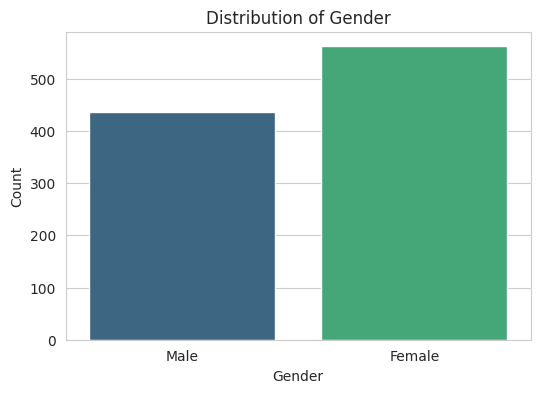

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Distribution of Gender
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


/tmp/ipykernel_17121/2065107690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Level', order=df['Level'].value_counts().index, palette='magma')


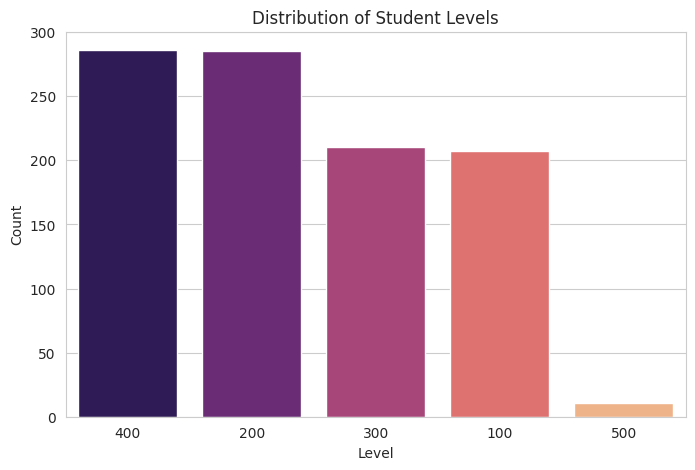

In [ ]:
# Distribution of Level
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Level', order=df['Level'].value_counts().index, palette='magma')
plt.title('Distribution of Student Levels')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()


/tmp/ipykernel_17121/3422906609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Hall of Residence', order=df['Hall of Residence'].value_counts().index, palette='cividis')


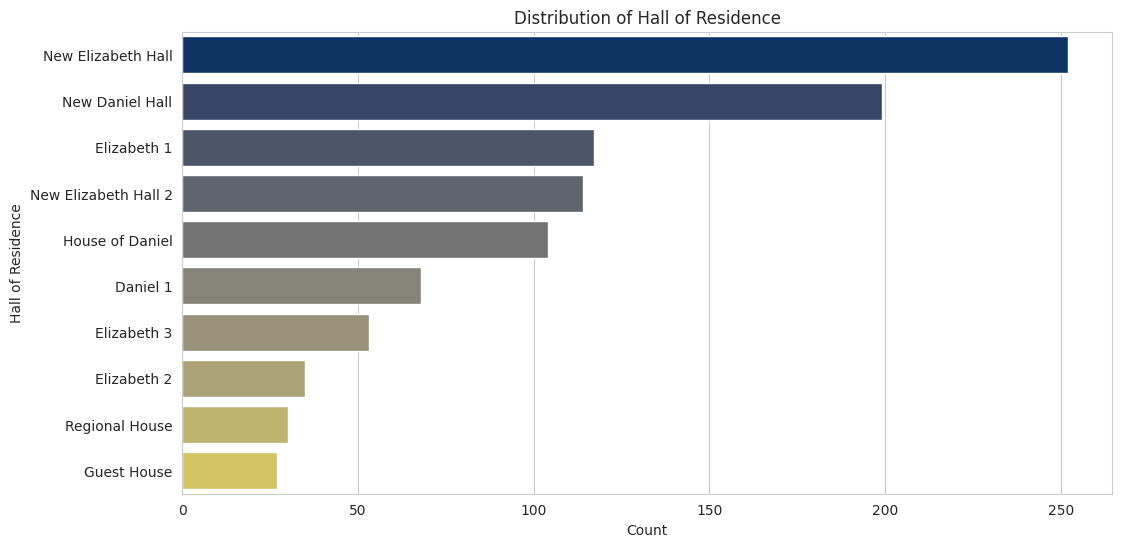

In [ ]:
# Distribution of Hall of Residence
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Hall of Residence', order=df['Hall of Residence'].value_counts().index, palette='cividis')
plt.title('Distribution of Hall of Residence')
plt.xlabel('Count')
plt.ylabel('Hall of Residence')
# plt.tight_layout()
plt.show()


/tmp/ipykernel_17121/785707784.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='When do you visit the clinic', order=df['When do you visit the clinic'].value_counts().index, palette='plasma')


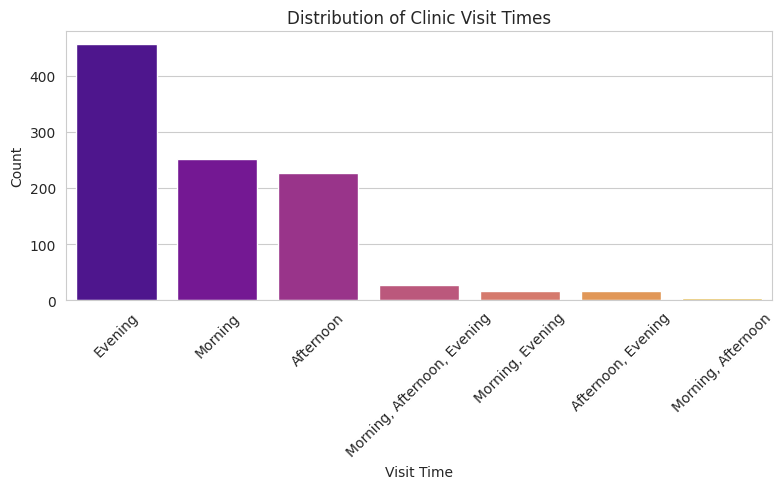

In [ ]:
# Distribution of 'When do you visit the clinic'
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='When do you visit the clinic', order=df['When do you visit the clinic'].value_counts().index, palette='plasma')
plt.title('Distribution of Clinic Visit Times')
plt.xlabel('Visit Time')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_17121/1227803313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Which unit made you dissatisfied or satisfied', order=df['Which unit made you dissatisfied or satisfied'].value_counts().index, palette='viridis')


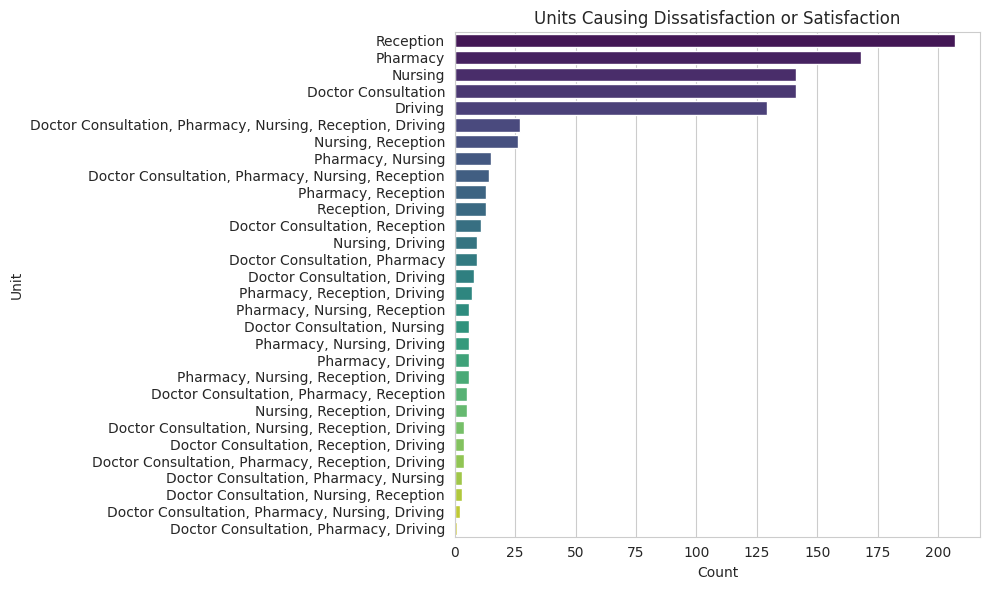

In [ ]:
# Distribution of 'Which unit made you dissatisfied or satisfied'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Which unit made you dissatisfied or satisfied', order=df['Which unit made you dissatisfied or satisfied'].value_counts().index, palette='viridis')
plt.title('Units Causing Dissatisfaction or Satisfaction')
plt.xlabel('Count')
plt.ylabel('Unit')
plt.tight_layout()
plt.show()


/tmp/ipykernel_17121/2773534347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Prescribed Drugs', order=df['Prescribed Drugs'].value_counts().index, palette='coolwarm')


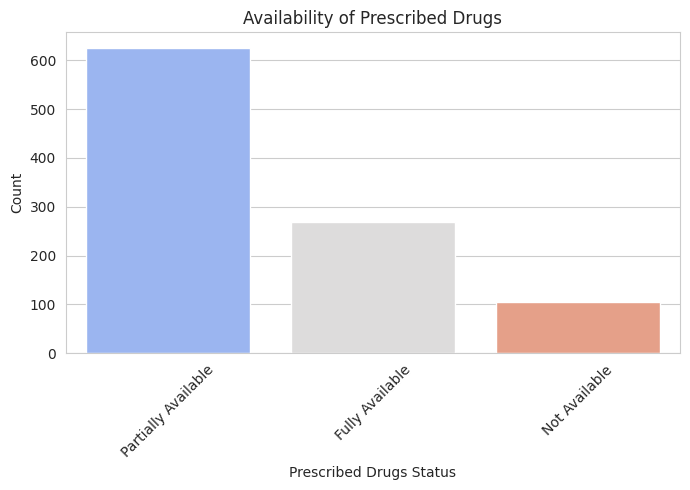

<Figure size 640x480 with 0 Axes>

In [ ]:
# Distribution of 'Prescribed Drugs'
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Prescribed Drugs', order=df['Prescribed Drugs'].value_counts().index, palette='coolwarm')
plt.title('Availability of Prescribed Drugs')
plt.xlabel('Prescribed Drugs Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig("Drugs")

/tmp/ipykernel_17121/3670834552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Functional Equipment', order=df['Functional Equipment'].value_counts().index, palette='Spectral')


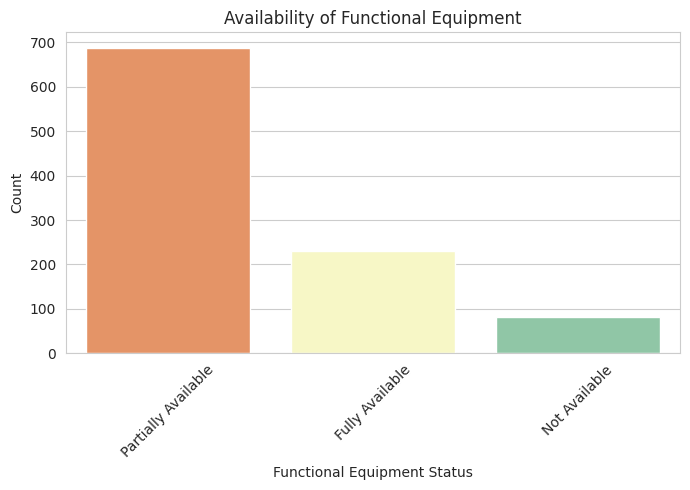

In [ ]:
# Distribution of 'Functional Equipment'
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Functional Equipment', order=df['Functional Equipment'].value_counts().index, palette='Spectral')
plt.title('Availability of Functional Equipment')
plt.xlabel('Functional Equipment Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_17121/588008159.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='How was the treatment like with the staff', palette='YlGnBu')


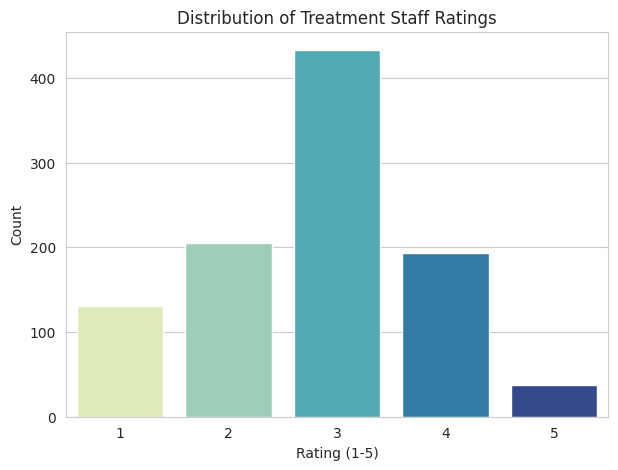

In [ ]:
# Distribution of 'How was the treatment like with the staff' (Rating)
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='How was the treatment like with the staff', palette='YlGnBu')
plt.title('Distribution of Treatment Staff Ratings')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')
plt.show()


/tmp/ipykernel_17121/2764999531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette='RdYlGn')


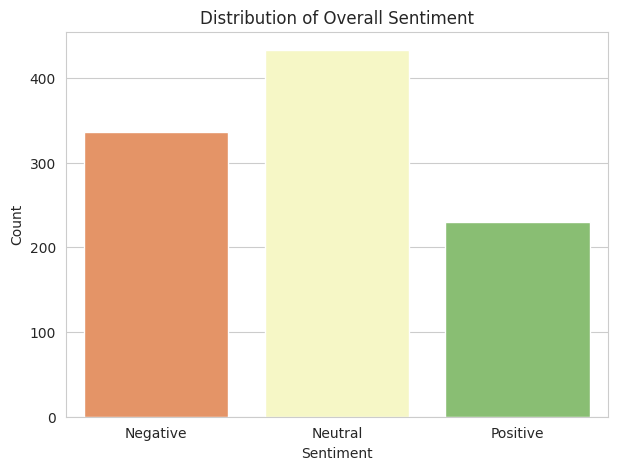

In [ ]:
# Distribution of Sentiment
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette='RdYlGn')
plt.title('Distribution of Overall Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


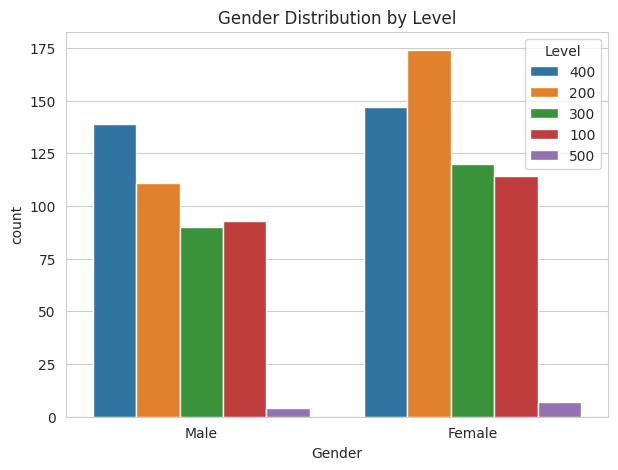

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=df['Gender'], hue=df['Level'])
plt.title('Gender Distribution by Level')
# plt.xlabel('Gender')
# plt.ylabel('Count')
plt.show()

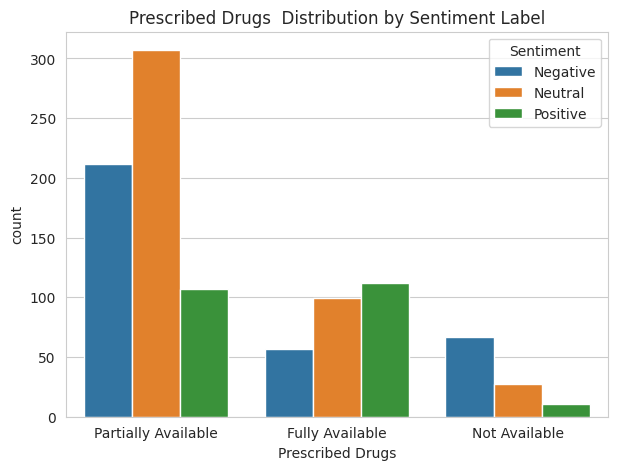

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=df['Prescribed Drugs'], hue=df['Sentiment'])
plt.title('Prescribed Drugs  Distribution by Sentiment Label')
# plt.xlabel('Gender')
# plt.ylabel('Count')
plt.show()

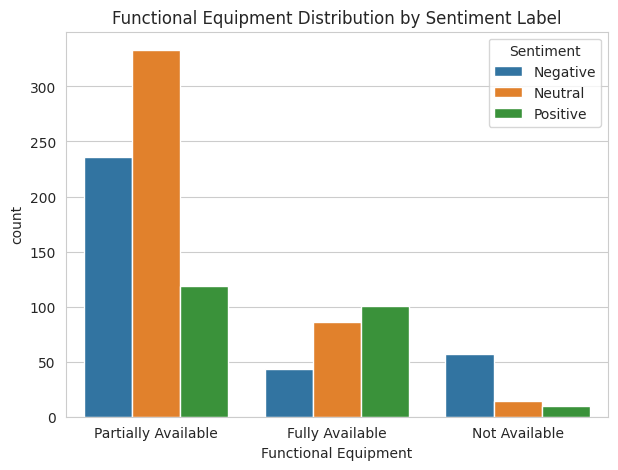

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=df['Functional Equipment'], hue=df['Sentiment'])
plt.title('Functional Equipment Distribution by Sentiment Label')
# plt.xlabel('Gender')
# plt.ylabel('Count')
plt.show()

### Sentiment Analysis by Categorical Variables

Let's visualize the distribution of sentiment across various categorical features to identify potential relationships.

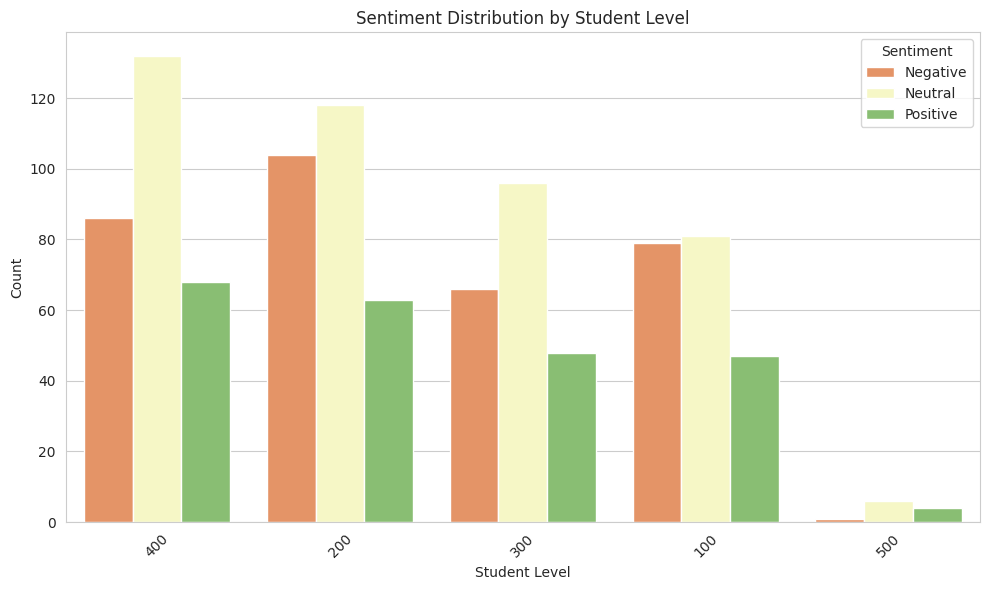

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment Distribution by Level
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Level', hue='Sentiment', order=df['Level'].value_counts().index, palette='RdYlGn')
plt.title('Sentiment Distribution by Student Level')
plt.xlabel('Student Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

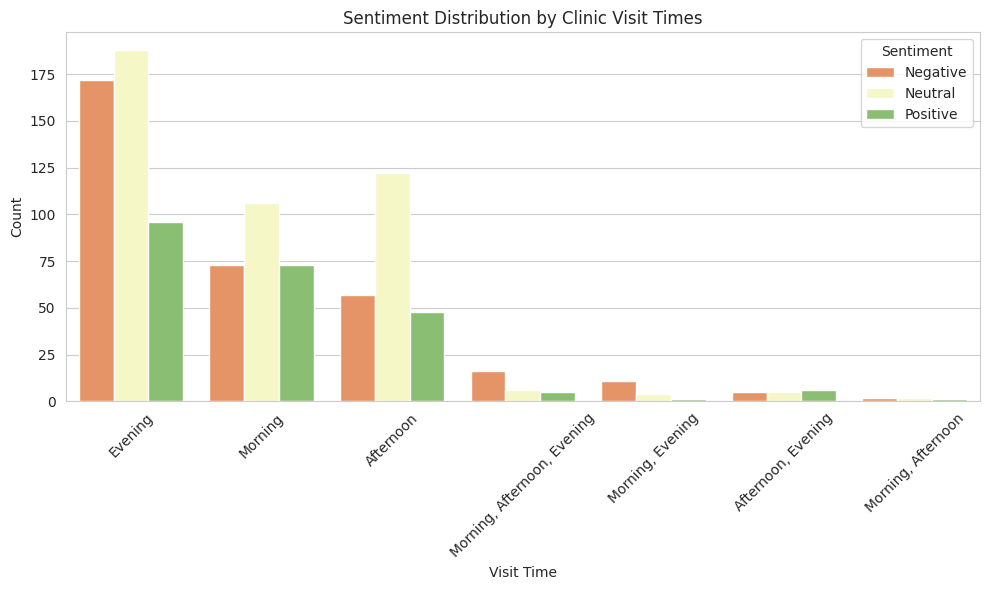

In [ ]:
# Sentiment Distribution by When do you visit the clinic
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='When do you visit the clinic', hue='Sentiment', order=df['When do you visit the clinic'].value_counts().index, palette='RdYlGn')
plt.title('Sentiment Distribution by Clinic Visit Times')
plt.xlabel('Visit Time')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

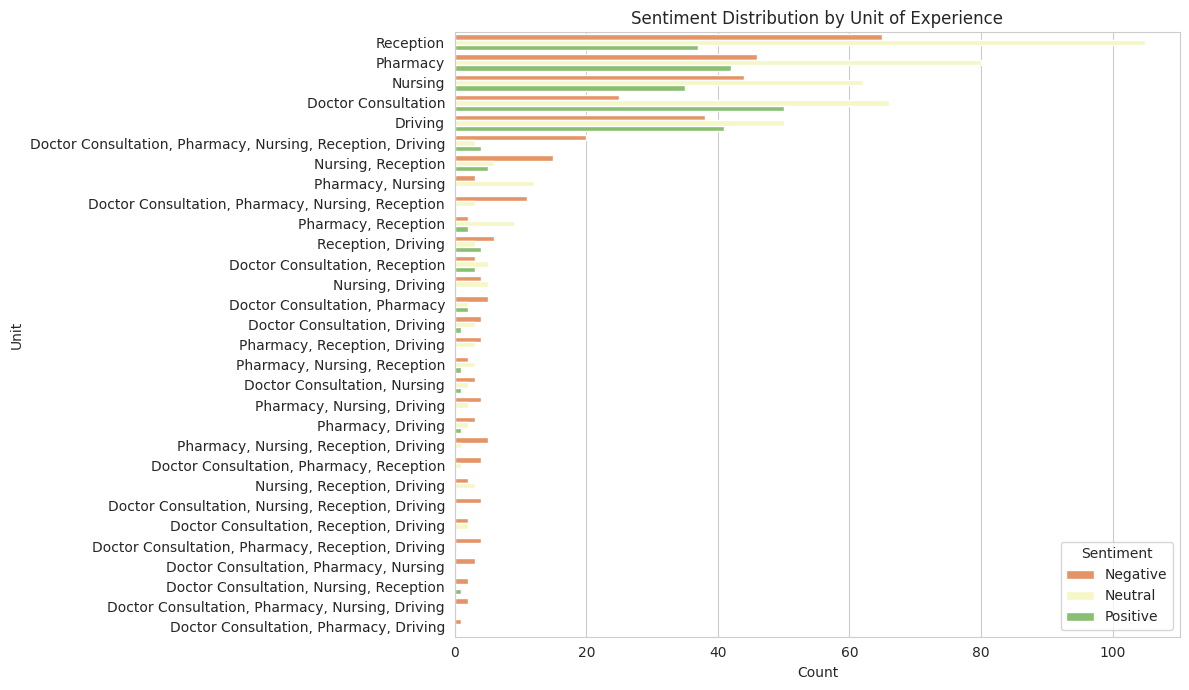

In [ ]:
# Sentiment Distribution by Which unit made you dissatisfied or satisfied
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='Which unit made you dissatisfied or satisfied', hue='Sentiment', order=df['Which unit made you dissatisfied or satisfied'].value_counts().index, palette='RdYlGn')
plt.title('Sentiment Distribution by Unit of Experience')
plt.xlabel('Count')
plt.ylabel('Unit')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

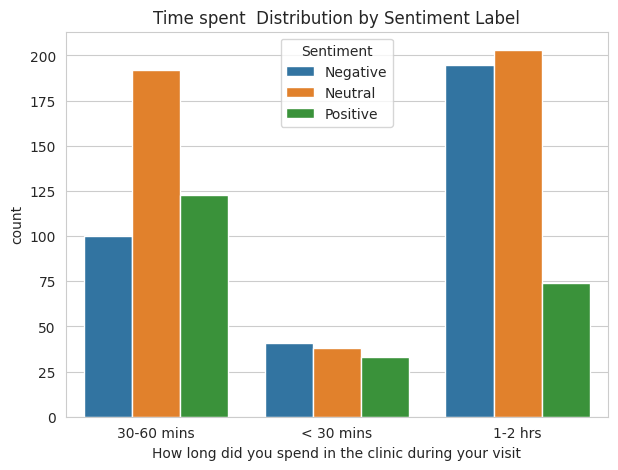

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=df['How long did you spend in the clinic during your visit'], hue=df['Sentiment'])
plt.title('Time spent  Distribution by Sentiment Label')
# plt.xlabel('Gender')
# plt.ylabel('Count')
plt.show()

In [ ]:
# df.isnull().sum()
# df.drop_duplicates()


### Cleaning of Reviews and Encoding of labels

In [ ]:
!pip install transformers datasets scikit-learn

In [ ]:
# !pip install torch

In [ ]:
print('Uninstalling and reinstalling torchvision to resolve ImportError...')
!pip uninstall -y torchvision datasets
!pip install torchvision datasets

Uninstalling and reinstalling torchvision to resolve ImportError...
Found existing installation: torchvision 0.27.0
Uninstalling torchvision-0.27.0:
  Successfully uninstalled torchvision-0.27.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
  Using cached torchvision-0.27.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
Using cached torchvision-0.27.0-cp312-cp312-manylinux_2_28_x86_64.whl (7.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 8.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0


In [ ]:
# Apply to your dataframe
df["cleaned_reviews"] = df["Reviews"].apply(advanced_clean_text)

In [ ]:
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["labels"] = df["Sentiment"].str.lower().map(label_map)

In [ ]:
display(df[['Reviews', 'cleaned_reviews', 'Sentiment', 'labels']].head())
df.info()

,Reviews,cleaned_reviews,Sentiment,labels
0,Slightly bad,slightly bad,Negative,0
1,It was okay,it was okay,Neutral,1
2,bad,bad,Negative,0
3,Good,good,Positive,2
4,Good,good,Neutral,1


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   Timestamp                                               999 non-null    object
 1   Gender                                                  999 non-null    object
 2   Level                                                   999 non-null    object
 3   Hall of Residence                                       999 non-null    object
 4   When do you visit the clinic                            999 non-null    object
 5   Which unit made you dissatisfied or satisfied           999 non-null    object
 6   Reviews                                                 999 non-null    object
 7   Why were you dissatisfied                               999 non-null    object
 8   How was the treatment like with the staff              

In [ ]:
# df['Why were you dissatisfied'].isnull().sum()
# df

In [ ]:
#HANDLING OF CLASS IMBALANCE(sentiment labels)
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["labels"]),
    y=df["labels"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class Weights:", class_weights)

Class Weights: tensor([0.9911, 0.7691, 1.4478])


In [ ]:
#Conversion of dataset(Pandas to Hugging Face)
from datasets import Dataset

dataset = Dataset.from_pandas(df[["cleaned_reviews", "labels"]])
dataset = dataset.train_test_split(test_size=0.2, seed=42) # Added seed for reproducibility

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['cleaned_reviews', 'labels', '__index_level_0__'],
        num_rows: 799
    })
    test: Dataset({
        features: ['cleaned_reviews', 'labels', '__index_level_0__'],
        num_rows: 200
    })
})


In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["cleaned_reviews"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Important: Clear any previous format settings that might be causing issues
dataset.reset_format()

dataset = dataset.map(tokenize, batched=True)

# Set format for PyTorch, now that 'labels' column exists and is named correctly
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/799 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs= 3, # Adjusted epochs based on discussion
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=2e-5, # Adjusted learning rate
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Define Metric Computation

To evaluate the model's performance during training and after, we need a function that computes relevant metrics (like accuracy, precision, recall, and F1-score) from the model's predictions. Since our dataset is imbalanced, looking beyond just accuracy is important.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np

def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    accuracy = accuracy_score(p.label_ids, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average='weighted')
    cm = confusion_matrix(p.label_ids, predictions)
    print(f"\nConfusion Matrix:\n{cm}")
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

### Initialize and Train the Trainer

Now, we'll instantiate the `Trainer` class, providing it with our model, training arguments, datasets, and the `compute_metrics` function. We'll also pass the `class_weights` calculated earlier to handle class imbalance in the loss function.

In [ ]:
# from transformers import Trainer

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=dataset["train"],
#     eval_dataset=dataset["test"],
#     compute_metrics=compute_metrics,
#     # For handling class imbalance
#     # Note: This requires custom Trainer or loss modification for BertForSequenceClassification
#     # For simplicity here, we'll rely on weighted metrics and batching.
#     # If you need direct class weighting in loss, you would typically modify the model's forward pass
#     # or use a custom Trainer. For now, weighted metrics are used.
# )

# # Train the model
# trainer.train()

The previous training attempt with the default `Trainer` failed because it did not explicitly handle the `labels` required for loss calculation, especially when incorporating `class_weights`.

The `CustomTrainer` (defined in a previous cell) is designed to address this issue by overriding the `compute_loss` method to correctly use `torch.nn.CrossEntropyLoss` with the `class_weights`.

Let's re-run the training process using the `CustomTrainer`.

In [ ]:
import torch
import numpy as np
from transformers import Trainer, RobertaForSequenceClassification, TrainingArguments, RobertaTokenizer
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Re-initialize the model to ensure it's on the correct device if not already
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

# Compute class weights (moved from cell 0923251f)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["labels"]),
    y=df["labels"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Convert DataFrame to Hugging Face Dataset (moved from cell RmSpKWddOQ_d)
dataset = Dataset.from_pandas(df[["cleaned_reviews", "labels"]])
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# Tokenization for RoBERTa (moved from cell 70b1698a)
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
def tokenize(batch):
    return tokenizer(
        batch["cleaned_reviews"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset.reset_format()
dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=2e-5,
    report_to="none"
)

# Initialize the custom trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
)

# Train the model with class weights
trainer.train()

deployment_dir = "./sentiment_results"

# 1. Save the best underlying structural transformer weights and model config setup
trainer.save_model(deployment_dir)

# 2. Save the vocabulary structure and merge mappings for clean text translation consistency
tokenizer.save_pretrained(deployment_dir)

print(f"\n🚀 System Assets Saved! Your production folder '{deployment_dir}' is populated and ready for Streamlit web serving.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/549 [00:00<?, ? examples/s]

Map:   0%|          | 0/138 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Confusion Matrix:
[[37  7 12]
 [24  8 21]
 [ 9  7 13]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=105, training_loss=1.06918519337972, metrics={'train_runtime': 2317.6597, 'train_samples_per_second': 0.711, 'train_steps_per_second': 0.045, 'total_flos': 108336949749504.0, 'train_loss': 1.06918519337972, 'epoch': 3.0})

In [ ]:
import pickle


In [ ]:
%%writefile app.py

import streamlit as st
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Load model
@st.cache_resource
def load_model():
    # Make sure 'sentiment_results' directory exists and contains your trained model
    model = BertForSequenceClassification.from_pretrained("./sentiment_results")
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    return model, tokenizer

model, tokenizer = load_model()

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

st.title("Sentiment Analysis App")

text = st.text_area("Enter Review")

if st.button("Predict"):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

    st.success(f"Sentiment: {label_map[pred]}")

Writing app.py


In [ ]:
!pip install streamlit
!python -m streamlit run app.py & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://soft-news-joke.loca.lt


In [ ]:
# import streamlit as st
# import torch
# import torch.nn.functional as F
# from transformers import RobertaTokenizer, RobertaForSequenceClassification
# import re
# import emoji
# import pandas as pd

# # Page Configuration
# st.set_page_config(
#     page_title="MTU Clinic Sentiment Audit Portal",
#     page_icon="🏥",
#     layout="wide"
# )

# # 1. Custom Text Preprocessing Pipeline (From Chapter 3 Methodology)
# def advanced_clean_text(text):
#     if not text:
#         return ""
#     # Convert to string and lowercase
#     text = str(text).lower()
#     # Demojize first (Turn 😊 into "smiling face")
#     text = emoji.demojize(text)
#     # Clean up the emoji text (Remove colons and underscores)
#     text = text.replace(":", " ").replace("_", " ")
#     # Use Regex to remove special characters (Keeping only letters and spaces)
#     text = re.sub(r'[^a-zA-Z\s]', '', text)
#     # Remove extra whitespace
#     text = re.sub(r'\s+', ' ', text).strip()
#     return text

# # 2. Optimized Model & Tokenizer Loader (Cached for Performance)
# @st.cache_resource
# def load_model():
#     # Points to your fine-tuned local weights; falls back to roberta-base if directory is empty
#     try:
#         model = RobertaForSequenceClassification.from_pretrained("./sentiment_results", num_labels=3)
#         tokenizer = RobertaTokenizer.from_pretrained("./sentiment_results")
#     except Exception:
#         # Fallback to base pretrained weights for testing the UI structure
#         model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)
#         tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

#     # Executed on CPU platform per hardware constraints
#     device = torch.device("cpu")
#     model.to(device)
#     return model, tokenizer

# model, tokenizer = load_model()

# # Label Mapping Array
# label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
# label_colors = {"Negative": "🔴", "Neutral": "🟡", "Positive": "🟢"}

# # Application Header
# st.title("🏥 Mountain Top University Clinic")
# st.subheader("Linguistic Auditing & Sentiment Analysis Portal")
# st.markdown("Transforming informal student narratives into institutional intelligence for proactive service delivery.")

# # Creating Tabs for Single Audits vs. Batch Processing Dashboard
# tab1, tab2 = st.tabs(["🎯 Real-Time Feedback Input", "📊 Batch Processing Dashboard"])

# # ==========================================
# # TAB 1: REAL-TIME FEEDBACK INPUT
# # ==========================================
# with tab1:
#     st.markdown("### Individual Narrative Analysis")
#     text_input = st.text_area(
#         "Enter Raw Student Review:",
#         placeholder="Type student feedback here (e.g., 'The nurse was nice but the wait time took too long...')"
#     )

#     if st.button("Run Sentiment Audit", type="primary"):
#         if text_input.strip() == "":
#             st.warning("Please enter some feedback text to analyze.")
#         else:
#             # Step A: Run through custom text cleaning pipeline
#             cleaned_text = advanced_clean_text(text_input)

#             # Step B: Tokenize input dimensions (Fixed length max_length=128)
#             inputs = tokenizer(
#                 cleaned_text,
#                 return_tensors="pt",
#                 truncation=True,
#                 padding=True,
#                 max_length=128
#             )

#             # Step C: Real-Time Inference
#             with torch.no_grad():
#                 outputs = model(**inputs)
#                 # Compute raw logits to probabilities using Softmax
#                 probabilities = F.softmax(outputs.logits, dim=1).flatten().tolist()
#                 pred_class = torch.argmax(outputs.logits, dim=1).item()

#             predicted_label = label_map[pred_class]

#             st.hr()

#             # Interface Layout Split
#             col1, col2 = st.columns([1, 1])

#             with col1:
#                 st.markdown("#### Audit Verdict")
#                 st.metric(
#                     label="Predicted Sentiment Class",
#                     value=f"{label_colors[predicted_label]} {predicted_label}"
#                 )
#                 with st.expander("View Normalized Text Output"):
#                     st.caption("This is the processed string passed directly to the tokenizer layer:")
#                     st.code(cleaned_text, language="text")

#             with col2:
#                 st.markdown("#### Confidence Visualization")
#                 # Structural representation of distribution weights
#                 conf_df = pd.DataFrame({
#                     "Sentiment": list(label_map.values()),
#                     "Confidence Probability": probabilities
#                 })

#                 # Render clean horizontal bar chart showing model confidence distribution
#                 st.bar_chart(data=conf_df, x="Sentiment", y="Confidence Probability", color="#4F8BF9")

#                 # Show explicit percentages
#                 for idx, row in conf_df.iterrows():
#                     st.caption(f"**{row['Sentiment']}**: {row['Confidence Probability']*100:.2f}%")

# # ==========================================
# # TAB 2: BATCH PROCESSING DASHBOARD
# # ==========================================
# with tab2:
#     st.markdown("### High-Volume Performance Metric Auditing")
#     st.markdown("Upload structural data files (CSV/Excel) containing multi-row student feedback lines to audit trends seamlessly.")

#     uploaded_file = st.file_uploader("Upload Student Feedback Dataset", type=["csv", "xlsx"])

#     if uploaded_file is not None:
#         # Load file into Pandas data structures
#         if uploaded_file.name.endswith(".csv"):
#             df = pd.read_csv(uploaded_file)
#         else:
#             df = pd.read_excel(uploaded_file)

#         text_column = st.selectbox("Select the column containing the Clinical Experience Reviews:", df.columns)

#         if st.button("Process Batch Corpus"):
#             with st.spinner("Executing deep learning matrix parallelization..."):
#                 results = []
#                 neg_conf, neu_conf, pos_conf = [], [], []

#                 for index, row in df.iterrows():
#                     raw_text = row[text_column]
#                     clean = advanced_clean_text(raw_text)

#                     inputs = tokenizer(clean, return_tensors="pt", truncation=True, padding=True, max_length=128)
#                     with torch.no_grad():
#                         outputs = model(**inputs)
#                         probs = F.softmax(outputs.logits, dim=1).flatten().tolist()
#                         pred = torch.argmax(outputs.logits, dim=1).item()

#                     results.append(label_map[pred])
#                     neg_conf.append(probs[0])
#                     neu_conf.append(probs[1])
#                     pos_conf.append(probs[2])

#                 # Inject performance logs back into original dataframe
#                 df["Audited Sentiment"] = results
#                 df["Negative Confidence"] = neg_conf
#                 df["Neutral Confidence"] = neu_conf
#                 df["Positive Confidence"] = pos_conf

#                 st.success(f"Successfully evaluated {len(df)} qualitative records!")

#                 # Breakdown Statistics Visualizations
#                 metric_col1, metric_col2, metric_col3 = st.columns(3)
#                 sentiment_counts = df["Audited Sentiment"].value_counts()

#                 metric_col1.metric("Negative Claims Count 🔴", sentiment_counts.get("Negative", 0))
#                 metric_col2.metric("Neutral Accounts Count 🟡", sentiment_counts.get("Neutral", 0))
#                 metric_col3.metric("Positive Accounts Count 🟢", sentiment_counts.get("Positive", 0))

#                 st.dataframe(df, use_container_width=True)

#                 # Download Button for the generated audit spreadsheet
#                 csv_buffer = df.to_csv(index=False).encode('utf-8')
#                 st.download_button(
#                     label="Download Complete Sentiment Audit Sheet",
#                     data=csv_buffer,
#                     file_name="MTU_Clinic_Sentiment_Audit_Report.csv",
#                     mime="text/csv"
#                 )

### Experimenting with DistilBERT

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

print("Initializing DistilBERT tokenizer...")
tokenizer_distilbert = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_distilbert(batch):
    return tokenizer_distilbert(
        batch["cleaned_reviews"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Create a new dataset object to avoid modifying the one used by RoBERTa
dataset_distilbert = Dataset.from_pandas(df[["cleaned_reviews", "labels"]])
dataset_distilbert = dataset_distilbert.train_test_split(test_size=0.2, seed=42)

print("Tokenizing dataset with DistilBERT tokenizer...")
dataset_distilbert.reset_format()
dataset_distilbert = dataset_distilbert.map(tokenize_distilbert, batched=True)
dataset_distilbert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Initializing DistilBERT model...")
model_distilbert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

Now, we will train the DistilBERT model using the same `CustomTrainer` and `training_args`.

In [ ]:
import torch
from transformers import Trainer # Ensure Trainer is imported if not already

# Reuse the CustomTrainer definition from before
# If it's not defined in the current scope, you might need to copy it here.
# For this example, assuming CustomTrainer is already defined and accessible.

print("Initializing CustomTrainer for DistilBERT...")
trainer_distilbert = CustomTrainer(
    model=model_distilbert,
    args=training_args, # Reuse the same training arguments
    train_dataset=dataset_distilbert["train"],
    eval_dataset=dataset_distilbert["test"],
    compute_metrics=compute_metrics,
)

print("Training DistilBERT model...")
trainer_distilbert.train()

print("Evaluating DistilBERT model...")
predictions_distilbert = np.argmax(trainer_distilbert.predict(dataset_distilbert["test"]).predictions, axis=1)
cm_distilbert = confusion_matrix(dataset_distilbert["test"]["labels"], predictions_distilbert)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_distilbert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('DistilBERT Sentiment Classification Confusion Matrix')
plt.show()

In [ ]:
# import torch
# from transformers import Trainer, BertForSequenceClassification

# # Re-define CustomTrainer to ensure it's available in the current scope if needed, though it was defined earlier.
# class CustomTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False):
#         labels = inputs.pop("labels")
#         outputs = model(**inputs)
#         logits = outputs.get("logits")
#         # Ensure class_weights are on the same device as the model
#         loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
#         loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
#         return (loss, outputs) if return_outputs else loss

# # Re-initialize the model (to ensure it's fresh for training)
# model = BertForSequenceClassification.from_pretrained(
#     "bert-base-uncased",
#     num_labels=3
# )

# # Initialize the custom trainer
# trainer = CustomTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=dataset["train"],
#     eval_dataset=dataset["test"],
#     compute_metrics=compute_metrics,
# )

# # Train the model with class weights
# trainer.train()

### Custom Trainer for Class Imbalance

To apply the `class_weights` we calculated earlier, we'll create a custom `Trainer` subclass. This custom `Trainer` will override the `compute_loss` method to use `torch.nn.CrossEntropyLoss` with our specified `class_weights`.

In [ ]:
# import torch
# from transformers import Trainer

# class CustomTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False):
#         labels = inputs.pop("labels")
#         outputs = model(**inputs)
#         logits = outputs.get("logits")
#         loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
#         loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
#         return (loss, outputs) if return_outputs else loss

# # Re-initialize the model to ensure it's on the correct device if not already
# model = BertForSequenceClassification.from_pretrained(
#     "bert-base-uncased",
#     num_labels=3
# )

# # Initialize the custom trainer
# trainer = CustomTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=dataset["train"],
#     eval_dataset=dataset["test"],
#     compute_metrics=compute_metrics,
# )

# # Train the model with class weights
# trainer.train()

This updated setup will now use the `class_weights` during training, which should help the model learn more effectively from the imbalanced sentiment labels.

The model training is now underway! The `Trainer` will save checkpoints and evaluate the model at the end of each epoch based on the metrics you defined. Once training is complete, the best model will be loaded, and you can then evaluate it further.

In [ ]:
# # Expand multi-option visit times into individual entries
# expanded_visits = df['When do you visit the clinic'].str.split(', ').explode()

# # Count the occurrences of each main visit time
# visit_time_distribution = expanded_visits.value_counts()

# print("Consolidated Distribution of Clinic Visit Times:")
# print(visit_time_distribution)

In [ ]:
# print(df['When do you visit the clinic'].value_counts())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'eval_results' is the output of trainer.evaluate()
# and you have your predictions ready:
predictions = np.argmax(trainer.predict(dataset["test"]).predictions, axis=1)
cm = confusion_matrix(dataset["test"]["labels"], predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Sentiment Classification Confusion Matrix')
plt.show()

In [ ]:
# pip install streamlit


# import streamlit as st
# import torch
# from transformers import BertTokenizer, BertForSequenceClassification

# # Load model
# @st.cache_resource
# def load_model():
#     model = BertForSequenceClassification.from_pretrained("./sentiment_results")
#     tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
#     return model, tokenizer

# model, tokenizer = load_model()

# label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# st.title("Sentiment Analysis App")

# text = st.text_area("Enter Review")

# if st.button("Predict"):
#     inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
#     outputs = model(**inputs)
#     pred = torch.argmax(outputs.logits, dim=1).item()

#     st.success(f"Sentiment: {label_map[pred]}")


In [ ]:
import emoji
import re

def advanced_clean_text(text):
    # 1. Convert to string and lowercase
    text = str(text).lower()

    # 2. Demojize first (Turn 😊 into "smiling face")
    # We do this BEFORE regex so the emojis aren't deleted
    text = emoji.demojize(text)

    # 3. Clean up the emoji text (Remove colons and underscores)
    text = text.replace(":", " ").replace("_", " ")

    # 4. Now use Regex to remove special characters
    # (Keeping only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text
